# ABP_PPG Dataset: Preprocessing + Inference

MIMIC-III data preprocessed by a different pipeline (not Kachuee).
PPG scale [0, 4.002] matches MIMIC training data — no normalization adaptation needed.

**Pipeline:**
1. Load .mat files → extract PPG (row 0) and ABP (row 1)
2. Crop to 1024 samples
3. Filter artifacts (ABP min < 0, flat PPG)
4. Normalize PPG via meta9.p
5. Save as `data/abp_ppg_test.p`
6. Inference: ApproximateNetwork → RefinementNetwork
7. Metrics: Waveform MAE, SBP/DBP/MAP error, BHS/AAMI grading

**Input:** `raw_data/ABP_PPG/*.mat` (5856 files, 2 segments each)
**Output:** `data/abp_ppg_test.p`

In [1]:
import numpy as np
import scipy.io
import pickle
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

FS = 125
SEGMENT_LENGTH = 1024  # model input length
BATCH_SIZE = 500

## 1. Load and Extract Segments

In [2]:
DATA_DIR = os.path.join('raw_data', 'ABP_PPG')
files = sorted(glob.glob(os.path.join(DATA_DIR, '*.mat')))
print(f'Total .mat files: {len(files)}')

# Normalization parameters from training
meta = pickle.load(open(os.path.join('data', 'meta9.p'), 'rb'))
min_ppg, max_ppg = meta['min_ppg'], meta['max_ppg']
min_abp, max_abp = meta['min_abp'], meta['max_abp']
print(f'meta9.p: PPG=[{min_ppg:.4f}, {max_ppg:.4f}], ABP=[{min_abp:.2f}, {max_abp:.2f}]')

Total .mat files: 5856
meta9.p: PPG=[0.0000, 4.0020], ABP=[50.00, 199.99]


In [3]:
# Extract all segments: PPG (row 0), ABP (row 1), crop to 1024
ppg_segments = []
abp_segments = []
file_info = []  # (filename, seg_idx) for traceability
errors = 0

for fpath in tqdm(files, desc='Loading .mat files'):
    fname = os.path.basename(fpath)
    try:
        mat = scipy.io.loadmat(fpath)
        sp = mat['signal_processing']
        for seg_idx in range(sp.shape[1]):
            seg = sp[0, seg_idx]
            sig = seg['signal']
            if isinstance(sig, np.ndarray) and sig.dtype == object:
                sig = sig.flat[0]
            sig = np.asarray(sig, dtype=np.float64)

            if sig.ndim != 2 or sig.shape[0] < 2 or sig.shape[1] < SEGMENT_LENGTH:
                continue

            ppg = sig[0, :SEGMENT_LENGTH]  # row 0 = PPG
            abp = sig[1, :SEGMENT_LENGTH]  # row 1 = ABP

            ppg_segments.append(ppg)
            abp_segments.append(abp)
            file_info.append((fname, seg_idx))
    except Exception as e:
        errors += 1

X_raw = np.array(ppg_segments, dtype=np.float64)
Y_raw = np.array(abp_segments, dtype=np.float64)

print(f'\nExtracted: {len(X_raw)} segments from {len(files) - errors} files ({errors} errors)')
print(f'X_raw (PPG): {X_raw.shape}, range=[{X_raw.min():.4f}, {X_raw.max():.4f}], mean={X_raw.mean():.4f}')
print(f'Y_raw (ABP): {Y_raw.shape}, range=[{Y_raw.min():.2f}, {Y_raw.max():.2f}], mean={Y_raw.mean():.2f}')

Loading .mat files: 100%|██████████| 5856/5856 [01:25<00:00, 68.32it/s]


Extracted: 11708 segments from 5854 files (2 errors)
X_raw (PPG): (11708, 1024), range=[0.0000, 4.0020], mean=1.5841
Y_raw (ABP): (11708, 1024), range=[-6753.96, 200.63], mean=88.01


## 2. Filter Artifacts

In [4]:
# Compute per-segment stats
ppg_std = X_raw.std(axis=1)
abp_min = Y_raw.min(axis=1)
abp_max = Y_raw.max(axis=1)
abp_mean = Y_raw.mean(axis=1)

# Filters
mask_ppg_flat = ppg_std >= 0.01   # exclude flat PPG
mask_abp_neg = abp_min >= 0       # exclude negative ABP (artifact)
mask_abp_range = (abp_min >= 20) & (abp_max <= 300)  # physiological range
mask_nan = ~(np.isnan(X_raw).any(axis=1) | np.isnan(Y_raw).any(axis=1))

# Combined
mask = mask_ppg_flat & mask_abp_neg & mask_abp_range & mask_nan

print(f'Filter results:')
print(f'  Total segments:         {len(X_raw)}')
print(f'  Flat PPG (std < 0.01):  {(~mask_ppg_flat).sum()} removed')
print(f'  ABP < 0 (artifact):     {(~mask_abp_neg).sum()} removed')
print(f'  ABP out of [20, 300]:   {(~mask_abp_range).sum()} removed')
print(f'  NaN:                    {(~mask_nan).sum()} removed')
print(f'  After filtering:        {mask.sum()} segments')

X_filt = X_raw[mask]
Y_filt = Y_raw[mask]

Filter results:
  Total segments:         11708
  Flat PPG (std < 0.01):  0 removed
  ABP < 0 (artifact):     2 removed
  ABP out of [20, 300]:   2 removed
  NaN:                    0 removed
  After filtering:        11706 segments


## 3. Normalize PPG

ABP_PPG has PPG in range [0, 4.002] — identical to MIMIC training data.
Apply meta9.p normalization directly: `(PPG - min_ppg) / (max_ppg - min_ppg)`

In [5]:
X_norm = ((X_filt - min_ppg) / (max_ppg - min_ppg)).astype(np.float32)

# Sanity checks
frac_01 = ((X_norm >= 0) & (X_norm <= 1)).mean()
print(f'Normalized PPG:')
print(f'  range: [{X_norm.min():.4f}, {X_norm.max():.4f}]')
print(f'  mean:  {X_norm.mean():.4f}')
print(f'  % in [0, 1]: {frac_01*100:.1f}%')
print(f'\nGround truth ABP (mmHg):')
print(f'  range: [{Y_filt.min():.1f}, {Y_filt.max():.1f}]')
print(f'  mean:  {Y_filt.mean():.1f}')

Normalized PPG:
  range: [0.0000, 1.0000]
  mean:  0.3959
  % in [0, 1]: 100.0%

Ground truth ABP (mmHg):
  range: [27.2, 200.6]
  mean:  88.0


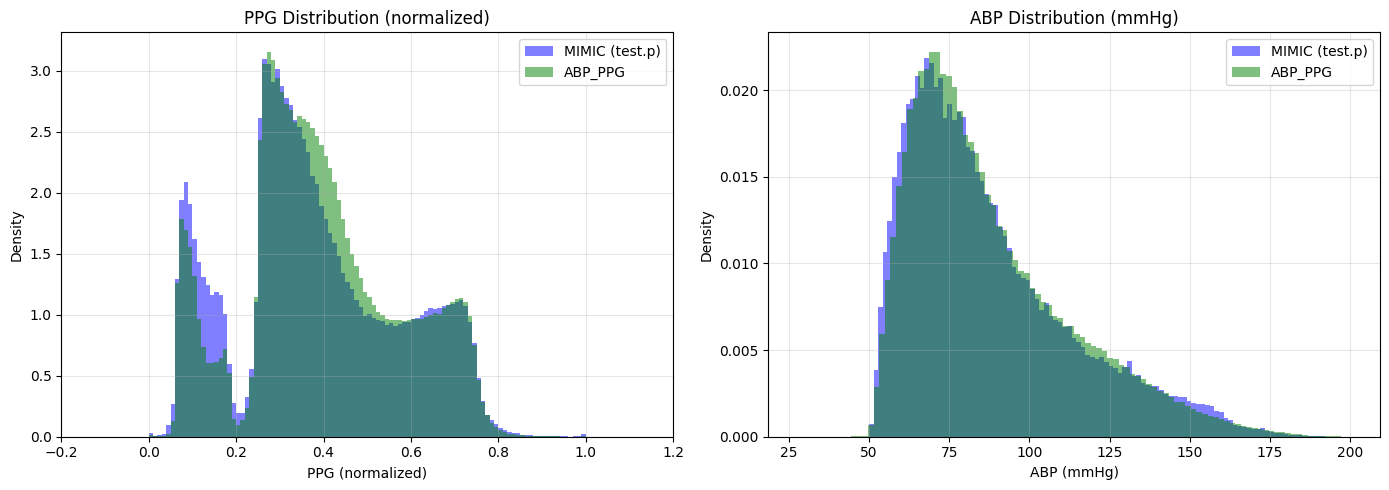

In [6]:
# Compare distribution with MIMIC test data
dt_mimic = pickle.load(open(os.path.join('data', 'test.p'), 'rb'))
X_mimic = dt_mimic['X_test'].flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PPG distribution
ax = axes[0]
ax.hist(X_mimic, bins=100, alpha=0.5, label='MIMIC (test.p)', density=True, color='blue')
ax.hist(X_norm.flatten(), bins=100, alpha=0.5, label='ABP_PPG', density=True, color='green')
ax.set_title('PPG Distribution (normalized)')
ax.set_xlabel('PPG (normalized)')
ax.set_ylabel('Density')
ax.set_xlim(-0.2, 1.2)
ax.legend()
ax.grid(True, alpha=0.3)

# ABP distribution
Y_mimic = dt_mimic['Y_test'].flatten() * (max_abp - min_abp) + min_abp
ax = axes[1]
ax.hist(Y_mimic, bins=100, alpha=0.5, label='MIMIC (test.p)', density=True, color='blue')
ax.hist(Y_filt.flatten(), bins=100, alpha=0.5, label='ABP_PPG', density=True, color='green')
ax.set_title('ABP Distribution (mmHg)')
ax.set_xlabel('ABP (mmHg)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Save Test Data

In [7]:
X_test = X_norm.reshape(-1, SEGMENT_LENGTH, 1)
Y_test = Y_filt.reshape(-1, SEGMENT_LENGTH, 1).astype(np.float32)

abp_ppg_data = {
    'X_test': X_test,       # PPG normalized via meta9.p
    'Y_test': Y_test,       # ABP in mmHg
    'source': 'ABP_PPG (MIMIC-III, alternative preprocessing)',
    'fs': FS,
    'segment_length': SEGMENT_LENGTH,
    'n_segments': len(X_test),
    'normalization': 'meta9p_direct',
    'normalization_params': {
        'method': 'meta9p_direct',
        'min_ppg': float(min_ppg),
        'max_ppg': float(max_ppg),
    },
    'filtering': {
        'ppg_std_min': 0.01,
        'abp_min_threshold': 0,
        'abp_range': [20, 300],
    },
}

output_path = os.path.join('data', 'abp_ppg_test.p')
with open(output_path, 'wb') as f:
    pickle.dump(abp_ppg_data, f)

print(f'Saved to {output_path}')
print(f'  X_test: {X_test.shape}')
print(f'  Y_test: {Y_test.shape}')

Saved to data\abp_ppg_test.p
  X_test: (11706, 1024, 1)
  Y_test: (11706, 1024, 1)


## 5. Inference

In [8]:
import torch
from _models_pytorch import UNetDS64, MultiResUNet1D

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

approx_model = UNetDS64(in_channels=1, out_channels=1).to(device)
approx_model.load_state_dict(
    torch.load('models/approximate_state_dict.pth', map_location=device, weights_only=True))
approx_model.eval()

refine_model = MultiResUNet1D(n_channel=1).to(device)
refine_model.load_state_dict(
    torch.load('models/refinement_state_dict.pth', map_location=device, weights_only=True))
refine_model.eval()

print('Models loaded.')

Device: cuda
Models loaded.


In [ ]:
def run_inference(X_norm_2d, batch_size=BATCH_SIZE):
    """ApproxNet -> RefineNet -> denormalize to mmHg."""
    X = torch.tensor(
        X_norm_2d.reshape(-1, SEGMENT_LENGTH, 1),
        dtype=torch.float32)
    N = len(X)
    preds = []

    for start in range(0, N, batch_size):
        batch = X[start:start + batch_size].to(device)
        with torch.no_grad():
            approx_out = approx_model(batch)
            y = approx_out[0].permute(0, 2, 1).contiguous()
            refined = refine_model(y)
            refined = refined.permute(0, 2, 1).contiguous()
        pred_batch = refined.cpu().numpy() * (max_abp - min_abp) + min_abp
        preds.append(pred_batch[:, :, 0])

    return np.concatenate(preds, axis=0)


print(f'Running inference on {len(X_norm)} segments...')
pred_mmhg = run_inference(X_norm)
print(f'Predictions: shape={pred_mmhg.shape}, range=[{pred_mmhg.min():.1f}, {pred_mmhg.max():.1f}] mmHg')

## 6. Metrics

In [10]:
def compute_metrics(pred, gt, label=''):
    """Compute waveform MAE, SBP/DBP/MAP errors, BHS grading."""
    N = len(pred)
    mae_seg = np.mean(np.abs(pred - gt), axis=1)
    sbp_err = np.abs(pred.max(axis=1) - gt.max(axis=1))
    dbp_err = np.abs(pred.min(axis=1) - gt.min(axis=1))
    map_err = np.abs(pred.mean(axis=1) - gt.mean(axis=1))

    def bhs(err):
        return ((err <= 5).mean()*100, (err <= 10).mean()*100, (err <= 15).mean()*100)

    def bhs_grade(pct5, pct10, pct15):
        if pct5 >= 60 and pct10 >= 85 and pct15 >= 95: return 'A'
        elif pct5 >= 50 and pct10 >= 75 and pct15 >= 90: return 'B'
        elif pct5 >= 40 and pct10 >= 65 and pct15 >= 85: return 'C'
        else: return 'D'

    sbp_bhs = bhs(sbp_err)
    dbp_bhs = bhs(dbp_err)
    map_bhs = bhs(map_err)

    if label:
        print(f'\n{"=" * 60}')
        print(f'{label} (N={N})')
        print(f'{"=" * 60}')

    print(f'Waveform MAE: {mae_seg.mean():.2f} +/- {mae_seg.std():.2f} mmHg')
    print(f'  median: {np.median(mae_seg):.2f}, P95: {np.percentile(mae_seg, 95):.2f}')
    print(f'SBP err:  {sbp_err.mean():.2f} +/- {sbp_err.std():.2f} mmHg')
    print(f'DBP err:  {dbp_err.mean():.2f} +/- {dbp_err.std():.2f} mmHg')
    print(f'MAP err:  {map_err.mean():.2f} +/- {map_err.std():.2f} mmHg')

    print(f'\nBHS Grading:')
    print(f'{"":>4} {"<=5":>8} {"<=10":>8} {"<=15":>8} {"Grade":>8}')
    for name, b, g in [('SBP', sbp_bhs, bhs_grade(*sbp_bhs)),
                        ('DBP', dbp_bhs, bhs_grade(*dbp_bhs)),
                        ('MAP', map_bhs, bhs_grade(*map_bhs))]:
        print(f'{name:>4} {b[0]:>7.1f}% {b[1]:>7.1f}% {b[2]:>7.1f}% {g:>8}')

    # AAMI: ME +/- SD (signed errors, not absolute)
    sbp_signed = pred.max(axis=1) - gt.max(axis=1)
    dbp_signed = pred.min(axis=1) - gt.min(axis=1)
    map_signed = pred.mean(axis=1) - gt.mean(axis=1)
    print(f'\nAAMI (ME +/- SD):')
    print(f'  SBP: {sbp_signed.mean():.2f} +/- {sbp_signed.std():.2f} mmHg')
    print(f'  DBP: {dbp_signed.mean():.2f} +/- {dbp_signed.std():.2f} mmHg')
    print(f'  MAP: {map_signed.mean():.2f} +/- {map_signed.std():.2f} mmHg')
    print(f'  (AAMI requires |ME| <= 5 and SD <= 8)')

    return {
        'n': N,
        'mae': (mae_seg.mean(), mae_seg.std()),
        'mae_median': np.median(mae_seg),
        'sbp': (sbp_err.mean(), sbp_err.std()),
        'dbp': (dbp_err.mean(), dbp_err.std()),
        'map': (map_err.mean(), map_err.std()),
        'sbp_bhs': sbp_bhs, 'dbp_bhs': dbp_bhs, 'map_bhs': map_bhs,
        'sbp_grade': bhs_grade(*sbp_bhs),
        'dbp_grade': bhs_grade(*dbp_bhs),
        'map_grade': bhs_grade(*map_bhs),
        'aami_sbp': (sbp_signed.mean(), sbp_signed.std()),
        'aami_dbp': (dbp_signed.mean(), dbp_signed.std()),
        'aami_map': (map_signed.mean(), map_signed.std()),
        'mae_per_seg': mae_seg,
    }

In [11]:
# All segments
r_all = compute_metrics(pred_mmhg, Y_filt, label='ALL SEGMENTS')


ALL SEGMENTS (N=11706)
Waveform MAE: 12.37 +/- 6.32 mmHg
  median: 10.99, P95: 24.40
SBP err:  18.27 +/- 14.10 mmHg
DBP err:  7.55 +/- 6.72 mmHg
MAP err:  9.39 +/- 7.48 mmHg

BHS Grading:
          <=5     <=10     <=15    Grade
 SBP    17.7%    33.9%    49.5%        D
 DBP    44.2%    73.4%    87.9%        C
 MAP    34.3%    61.1%    79.9%        D

AAMI (ME +/- SD):
  SBP: 8.53 +/- 21.44 mmHg
  DBP: -1.25 +/- 10.03 mmHg
  MAP: 2.04 +/- 11.83 mmHg
  (AAMI requires |ME| <= 5 and SD <= 8)


In [12]:
# ABP in [50, 200] — physiological subset matching MIMIC training range
mask_physio = (Y_filt.min(axis=1) >= 50) & (Y_filt.max(axis=1) <= 200)
r_physio = compute_metrics(
    pred_mmhg[mask_physio], Y_filt[mask_physio],
    label='ABP IN [50, 200] mmHg')


ABP IN [50, 200] mmHg (N=11510)
Waveform MAE: 12.35 +/- 6.32 mmHg
  median: 10.95, P95: 24.40
SBP err:  18.27 +/- 14.09 mmHg
DBP err:  7.49 +/- 6.71 mmHg
MAP err:  9.35 +/- 7.47 mmHg

BHS Grading:
          <=5     <=10     <=15    Grade
 SBP    17.7%    33.9%    49.5%        D
 DBP    44.7%    73.7%    88.1%        C
 MAP    34.6%    61.3%    80.0%        D

AAMI (ME +/- SD):
  SBP: 8.43 +/- 21.47 mmHg
  DBP: -1.45 +/- 9.96 mmHg
  MAP: 1.89 +/- 11.82 mmHg
  (AAMI requires |ME| <= 5 and SD <= 8)


In [13]:
# Exclude top 5% MAE outliers
p95 = np.percentile(r_all['mae_per_seg'], 95)
mask_clean = r_all['mae_per_seg'] <= p95
r_clean = compute_metrics(
    pred_mmhg[mask_clean], Y_filt[mask_clean],
    label=f'EXCLUDING TOP 5% OUTLIERS (MAE <= {p95:.1f})')


EXCLUDING TOP 5% OUTLIERS (MAE <= 24.4) (N=11120)
Waveform MAE: 11.44 +/- 4.82 mmHg
  median: 10.66, P95: 20.77
SBP err:  17.23 +/- 13.01 mmHg
DBP err:  6.80 +/- 5.53 mmHg
MAP err:  8.35 +/- 5.94 mmHg

BHS Grading:
          <=5     <=10     <=15    Grade
 SBP    18.4%    35.3%    51.3%        D
 DBP    46.4%    76.7%    91.0%        C
 MAP    36.1%    64.3%    84.0%        D

AAMI (ME +/- SD):
  SBP: 8.51 +/- 19.85 mmHg
  DBP: -0.91 +/- 8.72 mmHg
  MAP: 2.24 +/- 10.00 mmHg
  (AAMI requires |ME| <= 5 and SD <= 8)


In [14]:
# ABP in [50, 200] + exclude top 5% — strictest filter
mask_strict = mask_physio & mask_clean
r_strict = compute_metrics(
    pred_mmhg[mask_strict], Y_filt[mask_strict],
    label='ABP IN [50, 200] + EXCLUDE TOP 5%')


ABP IN [50, 200] + EXCLUDE TOP 5% (N=10934)
Waveform MAE: 11.41 +/- 4.81 mmHg
  median: 10.61, P95: 20.77
SBP err:  17.23 +/- 13.01 mmHg
DBP err:  6.75 +/- 5.50 mmHg
MAP err:  8.32 +/- 5.93 mmHg

BHS Grading:
          <=5     <=10     <=15    Grade
 SBP    18.4%    35.3%    51.4%        D
 DBP    46.8%    77.0%    91.1%        C
 MAP    36.4%    64.5%    84.2%        D

AAMI (ME +/- SD):
  SBP: 8.43 +/- 19.87 mmHg
  DBP: -1.10 +/- 8.64 mmHg
  MAP: 2.11 +/- 10.00 mmHg
  (AAMI requires |ME| <= 5 and SD <= 8)


## 7. Comparison Table

In [15]:
def fmt(ms):
    return f'{ms[0]:.2f} +/- {ms[1]:.2f}'

rows = []
for name, r in [('All', r_all), ('[50,200]', r_physio),
                ('Clean (P95)', r_clean), ('[50,200]+Clean', r_strict)]:
    rows.append({
        'Subset': name,
        'N': r['n'],
        'MAE': fmt(r['mae']),
        'SBP err': fmt(r['sbp']),
        'DBP err': fmt(r['dbp']),
        'MAP err': fmt(r['map']),
        'SBP grade': r['sbp_grade'],
        'DBP grade': r['dbp_grade'],
        'MAP grade': r['map_grade'],
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

        Subset     N            MAE         SBP err       DBP err       MAP err SBP grade DBP grade MAP grade
           All 11706 12.37 +/- 6.32 18.27 +/- 14.10 7.55 +/- 6.72 9.39 +/- 7.48         D         C         D
      [50,200] 11510 12.35 +/- 6.32 18.27 +/- 14.09 7.49 +/- 6.71 9.35 +/- 7.47         D         C         D
   Clean (P95) 11120 11.44 +/- 4.82 17.23 +/- 13.01 6.80 +/- 5.53 8.35 +/- 5.94         D         C         D
[50,200]+Clean 10934 11.41 +/- 4.81 17.23 +/- 13.01 6.75 +/- 5.50 8.32 +/- 5.93         D         C         D


## 8. Waveform Visualization

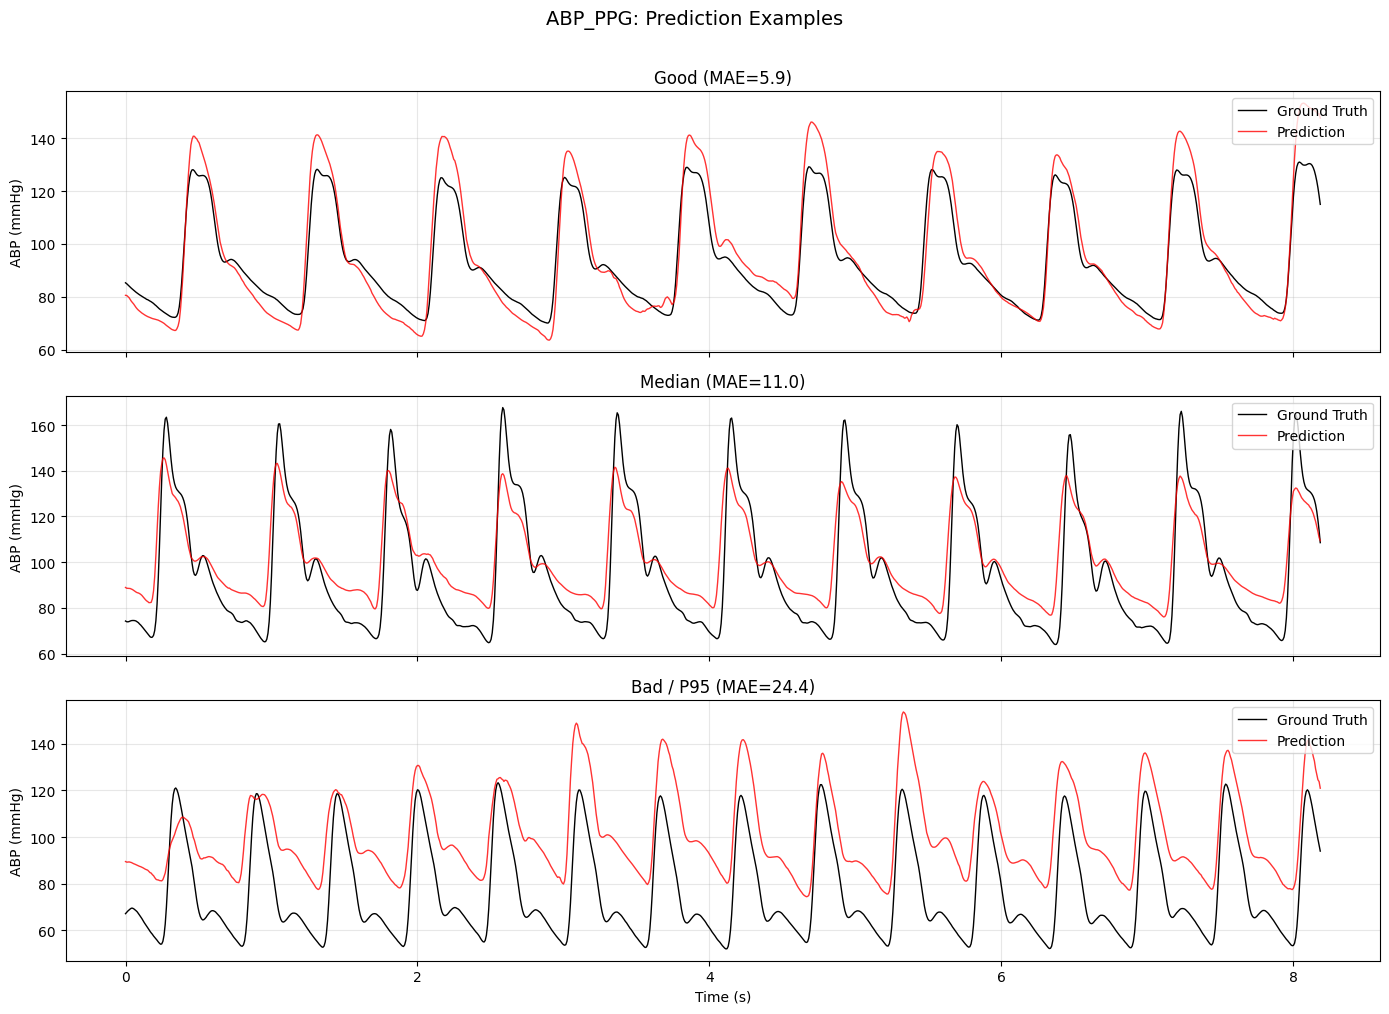

In [16]:
t = np.arange(SEGMENT_LENGTH) / FS

# Find segments with different MAE levels
mae_seg = r_all['mae_per_seg']
idx_good = np.argmin(np.abs(mae_seg - np.percentile(mae_seg, 10)))   # ~P10 = good
idx_med  = np.argmin(np.abs(mae_seg - np.median(mae_seg)))           # median
idx_bad  = np.argmin(np.abs(mae_seg - np.percentile(mae_seg, 95)))   # ~P95 = bad

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for i, (idx, title) in enumerate([
    (idx_good, f'Good (MAE={mae_seg[idx_good]:.1f})'),
    (idx_med,  f'Median (MAE={mae_seg[idx_med]:.1f})'),
    (idx_bad,  f'Bad / P95 (MAE={mae_seg[idx_bad]:.1f})')
]):
    ax = axes[i]
    ax.plot(t, Y_filt[idx], 'k-', label='Ground Truth', linewidth=1)
    ax.plot(t, pred_mmhg[idx], 'r-', label='Prediction', linewidth=1, alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel('ABP (mmHg)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
plt.suptitle('ABP_PPG: Prediction Examples', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

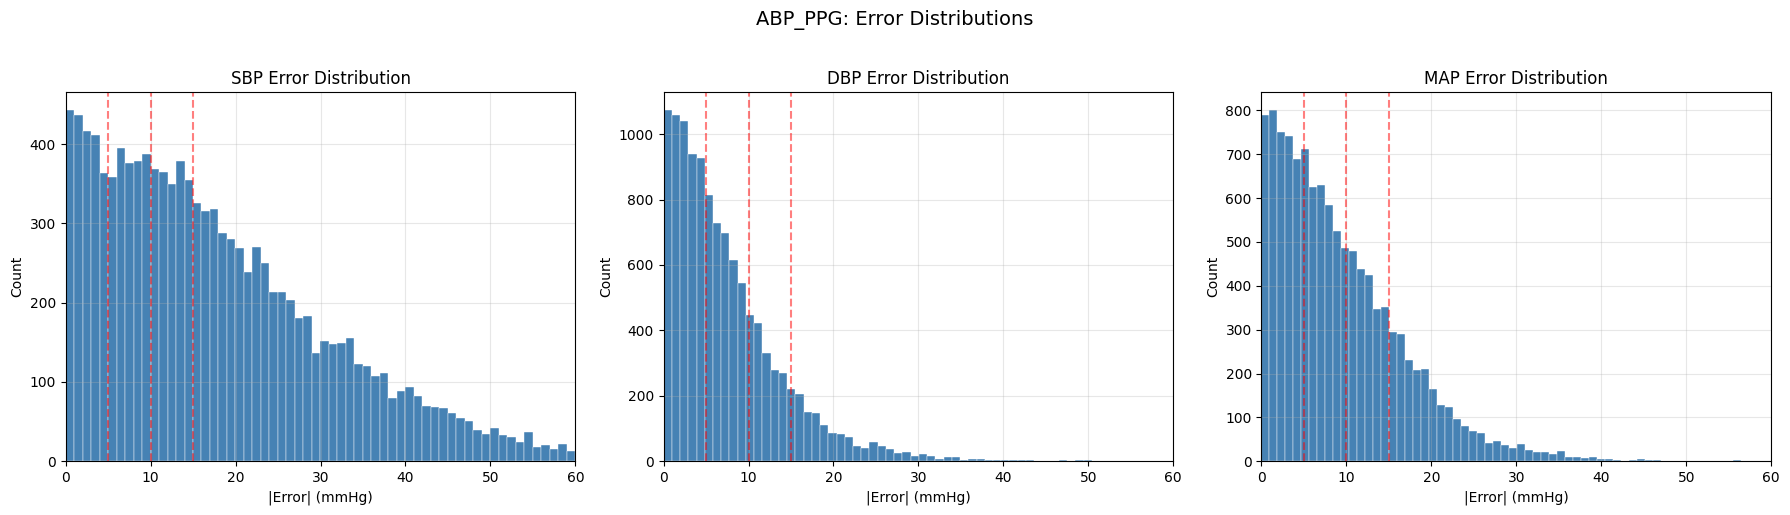

In [17]:
# Error distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sbp_err = np.abs(pred_mmhg.max(axis=1) - Y_filt.max(axis=1))
dbp_err = np.abs(pred_mmhg.min(axis=1) - Y_filt.min(axis=1))
map_err = np.abs(pred_mmhg.mean(axis=1) - Y_filt.mean(axis=1))

for i, (name, err) in enumerate([('SBP', sbp_err), ('DBP', dbp_err), ('MAP', map_err)]):
    ax = axes[i]
    ax.hist(err[err <= 60], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    for th in [5, 10, 15]:
        ax.axvline(th, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{name} Error Distribution')
    ax.set_xlabel('|Error| (mmHg)')
    ax.set_ylabel('Count')
    ax.set_xlim(0, 60)
    ax.grid(True, alpha=0.3)

plt.suptitle('ABP_PPG: Error Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

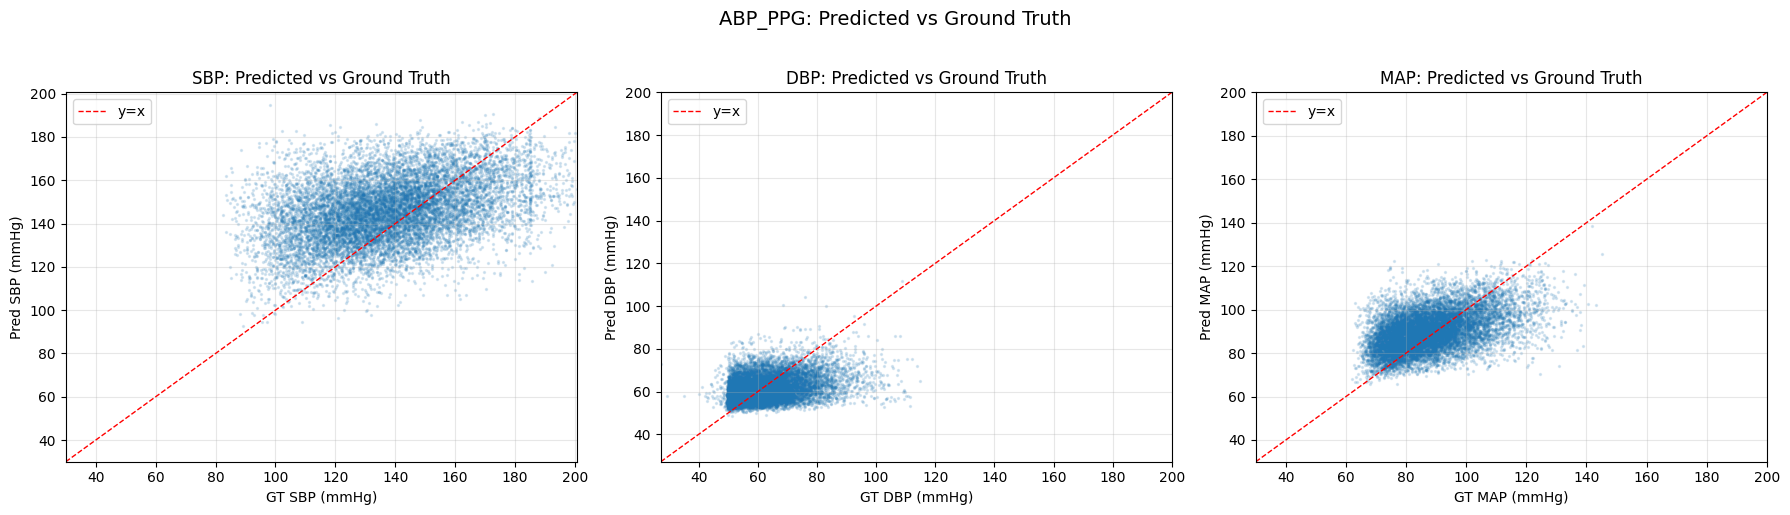

In [18]:
# Scatter: predicted vs ground truth
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sbp_gt = Y_filt.max(axis=1)
sbp_pred = pred_mmhg.max(axis=1)
dbp_gt = Y_filt.min(axis=1)
dbp_pred = pred_mmhg.min(axis=1)
map_gt = Y_filt.mean(axis=1)
map_pred = pred_mmhg.mean(axis=1)

for i, (name, gt, pr) in enumerate([
    ('SBP', sbp_gt, sbp_pred),
    ('DBP', dbp_gt, dbp_pred),
    ('MAP', map_gt, map_pred)
]):
    ax = axes[i]
    ax.scatter(gt, pr, s=2, alpha=0.15)
    lim = [min(gt.min(), pr.min(), 30), max(gt.max(), pr.max(), 200)]
    ax.plot(lim, lim, 'r--', linewidth=1, label='y=x')
    ax.set_title(f'{name}: Predicted vs Ground Truth')
    ax.set_xlabel(f'GT {name} (mmHg)')
    ax.set_ylabel(f'Pred {name} (mmHg)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lim)
    ax.set_ylim(lim)

plt.suptitle('ABP_PPG: Predicted vs Ground Truth', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Correlation Analysis

In [19]:
# Correlation between data features and prediction error
mae_seg = r_all['mae_per_seg']
ppg_std_f = X_filt.std(axis=1)
ppg_range_f = X_filt.max(axis=1) - X_filt.min(axis=1)
abp_sbp_f = Y_filt.max(axis=1)
abp_dbp_f = Y_filt.min(axis=1)
abp_mean_f = Y_filt.mean(axis=1)
abp_range_f = Y_filt.max(axis=1) - Y_filt.min(axis=1)

print('Correlation: feature vs MAE')
print('-' * 35)
for name, vals in [
    ('ppg_std', ppg_std_f),
    ('ppg_range', ppg_range_f),
    ('abp_sbp', abp_sbp_f),
    ('abp_dbp', abp_dbp_f),
    ('abp_mean', abp_mean_f),
    ('abp_range', abp_range_f),
]:
    r = np.corrcoef(vals, mae_seg)[0, 1]
    print(f'  corr({name:>12}, MAE) = {r:.3f}')

Correlation: feature vs MAE
-----------------------------------
  corr(     ppg_std, MAE) = -0.080
  corr(   ppg_range, MAE) = -0.061
  corr(     abp_sbp, MAE) = 0.085
  corr(     abp_dbp, MAE) = 0.217
  corr(    abp_mean, MAE) = 0.182
  corr(   abp_range, MAE) = -0.018


## 10. Cross-Dataset Comparison

In [20]:
# Compare with VitalDB results (if available)
print('\n' + '=' * 70)
print('CROSS-DATASET COMPARISON')
print('=' * 70)
print(f'{"Dataset":>15} {"N":>8} {"MAE":>20} {"SBP grade":>10} {"DBP grade":>10} {"MAP grade":>10}')
print('-' * 75)

# ABP_PPG (this notebook)
print(f'{"ABP_PPG (all)":>15} {r_all["n"]:>8} {fmt(r_all["mae"]):>20} '
      f'{r_all["sbp_grade"]:>10} {r_all["dbp_grade"]:>10} {r_all["map_grade"]:>10}')
print(f'{"ABP_PPG [50,200]":>15} {r_physio["n"]:>8} {fmt(r_physio["mae"]):>20} '
      f'{r_physio["sbp_grade"]:>10} {r_physio["dbp_grade"]:>10} {r_physio["map_grade"]:>10}')

print('\nReference (from previous experiments):')
print(f'{"MIMIC (paper)":>15} {"27260":>8} {"7.84":>20} {"A":>10} {"A":>10} {"A":>10}')
print(f'{"VitalDB (A)":>15} {"9400":>8} {"25.92":>20} {"D":>10} {"D":>10} {"D":>10}')


CROSS-DATASET COMPARISON
        Dataset        N                  MAE  SBP grade  DBP grade  MAP grade
---------------------------------------------------------------------------
  ABP_PPG (all)    11706       12.37 +/- 6.32          D          C          D
ABP_PPG [50,200]    11510       12.35 +/- 6.32          D          C          D

Reference (from previous experiments):
  MIMIC (paper)    27260                 7.84          A          A          A
    VitalDB (A)     9400                25.92          D          D          D
